In [1]:
import numpy as np
import pandas as pd
import statsmodels as sm

In [2]:
data= pd.read_csv("C:\\Users\\DELL User\\Downloads\\Dataset for Data Analytics(CSV).csv")

In [3]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [4]:
data.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [6]:
data.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
# Missing percentage for all columns
(data.isnull().sum() / len(data)) * 100

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

Handling Missing Data

In [ ]:
# mean imputation recommended for normally distributed data
#data['variable'].fillna(data['variable'].mean(), inplace=True)
# median imputation recommended for skewed distributed data

In [8]:
## UNIQUE COUPON CODES

print(data['CouponCode'].unique())

['SAVE10' 'FREESHIP' nan 'WINTER15']


In [9]:
print(data['CouponCode'].value_counts())

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64


In [10]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:

### since our missing data is greater than 25% we apply the k-nearest neighbor (KNN)
#KNN only works on numbers. CouponCode is text (object). So you need to temporarily convert it to numbers, impute, then convert back.

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

In [12]:
# creating a label encoder 

le = LabelEncoder()

In [13]:
## creating temporary matric column 

data['CouponCode_encoded'] = data['CouponCode'].copy()

In [14]:
## encode only on non missing rows 

mask = data['CouponCode'].notna()


data.loc[mask, 'CouponCode_encoded'] = le.fit_transform(data.loc[mask, 'CouponCode'])

# This says:
# mask → find rows where CouponCode is NOT missing
# Only encode those rows
# Leave missing rows as NaN so KNN knows what to fill

In [15]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponCode_encoded
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,0
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,0
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06,NaN
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,0
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,2


In [16]:
## we now convert our encoded coupon column into float . KNN omly reads floats ie. decimal numbers
data['CouponCode_encoded'] = data['CouponCode_encoded'].astype(float)


In [17]:
###KNN IMPUTER

knn_imputer = KNNImputer(n_neighbors=5)

data['CouponCode_encoded'] = knn_imputer.fit_transform(
    data[['CouponCode_encoded']]
)

In [18]:
## running the decimals imputed back into whole numbers
data['CouponCode_encoded'] = data['CouponCode_encoded'].round().astype(int)



In [19]:
## DECODING NUMBERS BACK TO TEXTS 

data['CouponCode'] = le.inverse_transform(data['CouponCode_encoded'])

In [20]:
## dropping the column used for encoding 

data.drop('CouponCode_encoded', axis=1, inplace=True)


In [21]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,SAVE10,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [22]:
print(data['CouponCode'].isnull().sum())   # Must print 0
print(data['CouponCode'].value_counts())   # 3 codes, total = 1200

0
CouponCode
SAVE10      595
FREESHIP    313
WINTER15    292
Name: count, dtype: int64


ISOLATING ANAOMALIES VIA INTER QUARTILE RANGE 

In [23]:
# IQR = Q3 - Q1
# Lower Bound = Q1 - 1.5 * IQR
# Upper Bound = Q3 + 1.5 * IQR
#Anything outside these bounds = OUTLIER

In [24]:
data

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,SAVE10,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [31]:
### only numerical column need IQR checks
numerical_cols=['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

In [29]:
## we pplot box pots for a 4 features to identify our outliers
import matplotlib.pyplot as plt
import seaborn as sns

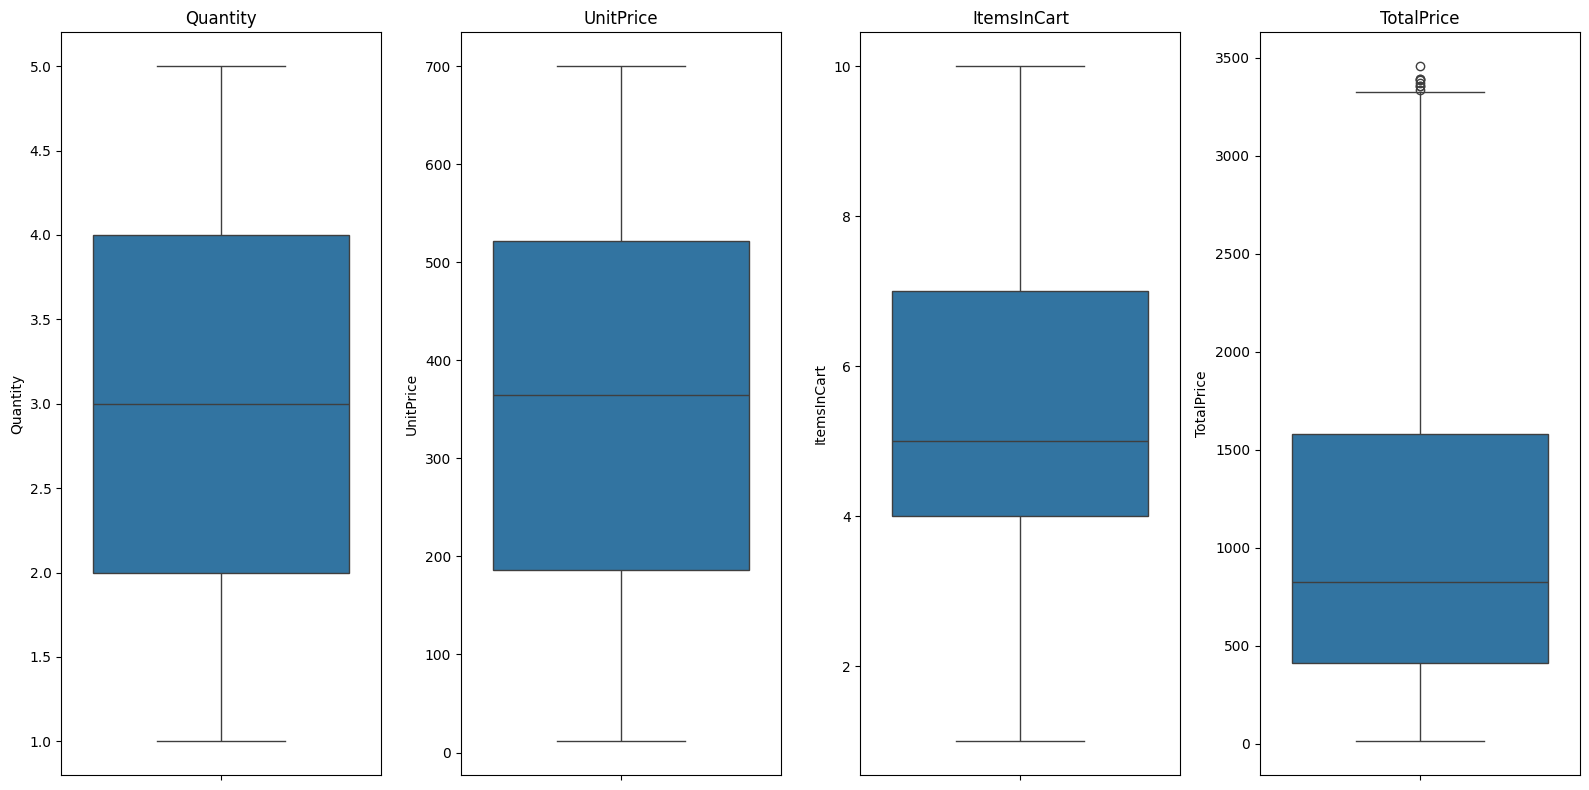

In [35]:

fig, axes = plt.subplots(1, 4, figsize=(16, 8))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
    print(f"{col}: {outliers} outliers found | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    # Cap them (Winsorization) #numpy.clip() simply pulls extreme values back to the boundary — it doesn't delete anything.
    data[col] = np.clip(data[col], lower_bound, upper_bound)

Quantity: 0 outliers found | Bounds: [-1.00, 7.00]
UnitPrice: 0 outliers found | Bounds: [-317.20, 1024.83]
ItemsInCart: 0 outliers found | Bounds: [-0.50, 11.50]
TotalPrice: 8 outliers found | Bounds: [-1341.41, 3330.41]


In [39]:

# Verify outliers are gone:
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
    print(f"{col}: {outliers} outliers remaining")

Quantity: 0 outliers remaining
UnitPrice: 0 outliers remaining
ItemsInCart: 0 outliers remaining
TotalPrice: 0 outliers remaining
